In [37]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Business Question

**What drives checkout abandonment, and how can we identify high-intent users before they leave?**

This notebook investigates the following questions:

1. Where do users drop off throughout the purchase funnel?
2. What behavioural characteristics distinguish purchasing users?
3. What factors are associated with checkout abandonment?

In [87]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import plotly.express as px
from scipy.stats import pointbiserialr

import matplotlib.pyplot as plt

from src.services import (
    load_funnel,
    load_checkout_abandonment,
    load_purchase_prediction,
    load_checkout_distribution
)

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [60]:
df_funnel = load_funnel()
df_checkout = load_checkout_abandonment()
df_prediction = load_purchase_prediction()

display(df_funnel.head())
display(df_checkout.head())
display(df_prediction.head())

,stage,sessions,overall_conversion_rate,stage_conversion_rate,stage_dropoff_rate
0,Page View,349545,100.00,100.00,0.00
1,View Item,76290,21.83,21.83,78.17
2,Add to Cart,15132,4.33,19.83,80.17
3,Begin Checkout,11088,3.17,73.28,26.72
4,Purchase,4845,1.39,43.70,56.30


,ga_session_id,user_pseudo_id,purchased,checkout_abandoned,session_start,session_end,session_duration_sec,total_events,total_engagement_time,pageviews,unique_pages,item_views,searches,add_to_cart,begin_checkout,add_shipping_info,add_payment_info,device_category,operating_system,country,session_source,acquisition_channel,session_medium,session_campaign
0,6636007571,7095040.3837298301,False,True,2020-12-10 22:56:52.837911+00:00,2020-12-11 09:32:11.738858+00:00,38118,32,142213,9,8,0,0,0,2,1,1,desktop,Web,France,(data deleted),Unknown,(data deleted),(data deleted)
1,3459549459,3147398.8003490202,False,True,2021-01-21 15:42:35.125546+00:00,2021-01-21 15:58:30.709392+00:00,955,42,224366,15,10,2,2,1,3,1,0,tablet,iOS,United States,(data deleted),Unknown,(data deleted),(data deleted)
2,1291896406,2337422.8102772361,False,True,2020-12-07 15:10:12.034031+00:00,2020-12-07 15:23:18.786301+00:00,786,42,640366,14,11,4,0,0,2,1,0,desktop,Web,India,(data deleted),Unknown,(data deleted),(data deleted)
3,341826832,50121199.4323445332,True,False,2020-11-30 20:28:35.924396+00:00,2020-11-30 20:40:29.683671+00:00,713,48,611217,12,7,1,0,1,4,2,3,mobile,Web,Canada,(data deleted),Unknown,(data deleted),(data deleted)
4,4299531234,39443462.9852246899,True,False,2020-11-02 12:16:10.348592+00:00,2020-11-02 12:39:09.975539+00:00,1379,57,455990,21,17,3,0,0,1,1,2,mobile,iOS,United States,(data deleted),Unknown,(data deleted),(data deleted)


,session_duration_sec,total_events,total_engagement_time,pageviews,unique_pages,item_views,searches,add_to_cart,begin_checkout,add_shipping_info,add_payment_info,device_category,operating_system,country,session_source,acquisition_channel,session_medium,session_campaign,engagement_per_event,item_view_rate,checkout_ratio,purchased
0,40,19,15856,6,4,0,0,0,2,1,0,mobile,Android,United States,NaN,Unknown,NaN,NaN,834.526316,0.000000,0.0,False
1,33,15,22006,3,4,1,0,1,2,1,0,mobile,Web,United States,NaN,Unknown,NaN,NaN,1467.066667,0.333333,2.0,False
2,40,16,21801,3,4,1,0,2,2,1,0,mobile,Web,Taiwan,NaN,Unknown,NaN,NaN,1362.562500,0.333333,1.0,False
3,1300,171,1080301,48,18,17,0,6,12,6,3,desktop,Web,United States,NaN,Unknown,NaN,NaN,6317.549708,0.354167,2.0,True
4,145,28,128770,10,7,0,0,0,1,1,1,mobile,Web,United States,(data deleted),Unknown,(data deleted),(data deleted),4598.928571,0.000000,0.0,False


## 1. Funnel Analysis

,stage,sessions,overall_conversion_rate,stage_conversion_rate,stage_dropoff_rate
0,Page View,349545,100.00,100.00,0.00
1,View Item,76290,21.83,21.83,78.17
2,Add to Cart,15132,4.33,19.83,80.17
3,Begin Checkout,11088,3.17,73.28,26.72
4,Purchase,4845,1.39,43.70,56.30


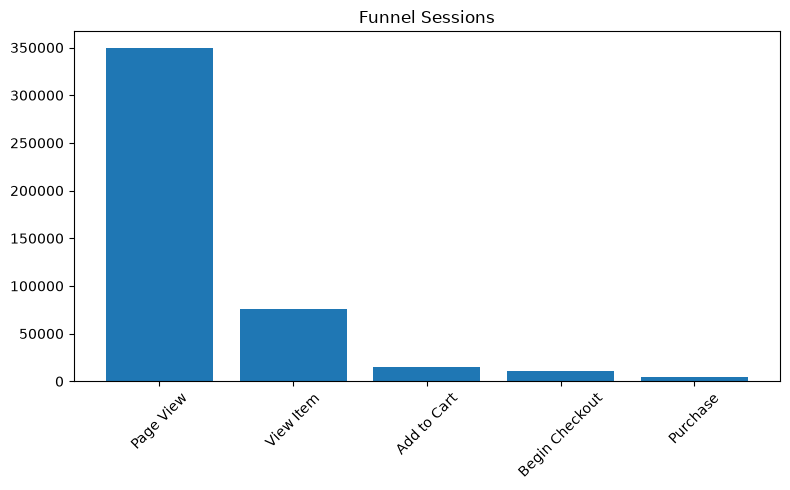

,stage,overall_conversion_rate,stage_conversion_rate,stage_dropoff_rate
0,Page View,100.00,100.00,0.00
1,View Item,21.83,21.83,78.17
2,Add to Cart,4.33,19.83,80.17
3,Begin Checkout,3.17,73.28,26.72
4,Purchase,1.39,43.70,56.30


In [61]:
display(df_funnel)

plt.figure(figsize=(8,5))
plt.bar(df_funnel["stage"], df_funnel["sessions"])
plt.xticks(rotation=45)
plt.title("Funnel Sessions")
plt.tight_layout()
plt.show()

display(
    df_funnel[
        [
            "stage",
            "overall_conversion_rate",
            "stage_conversion_rate",
            "stage_dropoff_rate"
        ]
    ]
)


### Insight

The conversion funnel reveals substantial user drop-off throughout the purchasing journey. While all sessions begin with a page view, only **21.83%** of sessions progress to viewing a product, and just **4.33%** eventually add an item to the cart.

The most significant loss occurs before users demonstrate purchase intent. Nearly **78%** of sessions leave the funnel before reaching the product detail page, while an additional **80%** of product viewers do not proceed to add an item to the cart. These results suggest that improving product discovery, product presentation, and purchase motivation may have an even greater impact than optimizing the checkout process alone.

Among users who initiate checkout, only **43.70%** complete a purchase, resulting in a checkout abandonment rate of **56.30%**. These findings indicate that improvements to both product engagement and the checkout experience could substantially increase overall conversion.

### Key Takeaways

- Only **1.39%** of all sessions result in a completed purchase.
- The largest drop-off occurs between **View Item** and **Add to Cart**.
- More than half of checkout sessions are abandoned before purchase.
- Both product engagement and checkout optimization represent high-impact opportunities for improving conversion.

## 2. Purchase Behaviour Analysis

### 2.1 Purchase Likelihood by User Activity

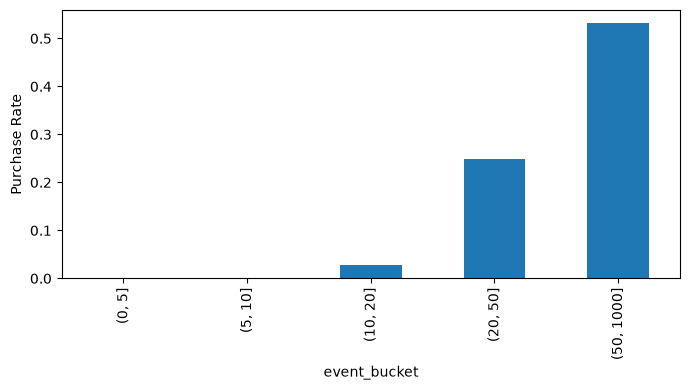

In [66]:
purchase_rate = (
    pd.cut(
        df_checkout["total_events"],
        bins=[0,5,10,20,50,1000]
    )
)

tmp = (
    df_checkout
    .assign(event_bucket=purchase_rate)
    .groupby("event_bucket")["purchased"]
    .mean()
)

tmp.plot(kind="bar", figsize=(7,4))
plt.ylabel("Purchase Rate")
plt.tight_layout()
plt.show()

### Overall Findings

Comparing purchasing and non-purchasing sessions reveals several consistent behavioural patterns.

Purchased sessions generally demonstrate **higher levels of engagement**, including longer session durations, more user interactions, and substantially greater engagement time. Although purchasers visit slightly fewer pages on average, they appear to navigate the platform more efficiently, suggesting a more focused purchase journey rather than extensive browsing.

Purchase likelihood also increases significantly with user activity. Sessions containing a larger number of events exhibit considerably higher purchase rates, indicating that user engagement is strongly associated with purchase intent. This trend suggests that interaction intensity is one of the most important behavioural signals for identifying high-intent users.

By contrast, purchase rates vary only slightly across different device categories, indicating that **behavioural metrics are more informative than device characteristics** when distinguishing purchasers from non-purchasers. Differences across acquisition sources are observable, although channels with very small sample sizes should be interpreted cautiously.

Overall, these findings indicate that **user engagement is the strongest behavioural indicator of purchase intent**. Session-level engagement features therefore provide a solid foundation for the purchase intent prediction model developed in the next stage of this project.

## 3. Checkout Abandonment Analysis

### 3.1 Behavioural Differences Between Completed and Abandoned Checkouts

In [88]:
behavior_cols = [
    "session_duration_sec",
    "total_events",
    "total_engagement_time",
    "pageviews",
    "unique_pages",
    "item_views",
    "searches"
]

summary = (
    df_checkout
    .groupby("purchased")[behavior_cols]
    .mean()
    .round(2)
)

display(summary)

,session_duration_sec,total_events,total_engagement_time,pageviews,unique_pages,item_views,searches
purchased,,,,,,,
False,2893.19,103.33,526353.5,35.26,25.52,14.79,0.59
True,3117.05,108.05,874194.36,31.18,16.16,13.47,0.37


### Insight

Users who successfully complete a purchase generally spend slightly more time on the platform, generate more events, and accumulate substantially higher engagement time than users who abandon the checkout process.

Interestingly, abandoned sessions tend to visit more pages, browse more unique pages, view more products, and perform more searches before leaving the checkout flow. This suggests that checkout abandonment is not necessarily caused by a lack of engagement. Instead, users who abandon may spend additional time comparing products, evaluating alternatives, or hesitating before making a final purchase decision.

These findings indicate that engagement alone cannot fully explain checkout abandonment. Other factors, such as pricing, payment friction, shipping concerns, or purchase uncertainty, may also influence the final purchasing decision.

### 3.2 Checkout Performance by Device

In [70]:
device = (
    df_checkout.groupby("device_category")["checkout_abandoned"]
      .agg(["count","mean"])
      .reset_index()
)

device["abandonment_rate"] = device["mean"]*100

device

,device_category,count,mean,abandonment_rate
0,desktop,6383,0.569168,56.91681
1,mobile,4465,0.554535,55.453527
2,tablet,240,0.570833,57.083333


In [75]:
device_summary = (
    df_prediction
    .groupby("device_category")
    .agg(
        Sessions=("purchased", "count"),
        Purchase_Rate=("purchased", "mean"),
        Avg_Pageviews=("pageviews", "mean"),
        Avg_Item_Views=("item_views", "mean"),
        Avg_Add_to_Cart=("add_to_cart", "mean"),
        Avg_Checkout=("begin_checkout", "mean")
    )
    .round(2)
    .sort_values("Purchase_Rate", ascending=False)
)

device_summary

,Sessions,Purchase_Rate,Avg_Pageviews,Avg_Item_Views,Avg_Add_to_Cart,Avg_Checkout
device_category,,,,,,
mobile,4465,0.45,33.14,14.03,2.71,3.51
desktop,6383,0.43,33.68,14.31,2.68,3.49
tablet,240,0.43,34.4,15.05,2.67,3.26


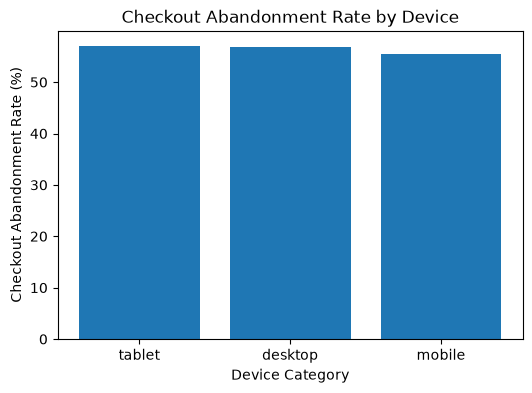

In [67]:
checkout_device = (
    df_checkout.groupby("device_category")["checkout_abandoned"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

checkout_device["checkout_abandoned"] *= 100

plt.figure(figsize=(6,4))
plt.bar(
    checkout_device["device_category"],
    checkout_device["checkout_abandoned"]
)
plt.ylabel("Checkout Abandonment Rate (%)")
plt.xlabel("Device Category")
plt.title("Checkout Abandonment Rate by Device")
plt.show()

In [76]:
behaviour = (
    df_prediction
    .groupby("device_category")[
        [
            "pageviews",
            "item_views",
            "add_to_cart",
            "begin_checkout"
        ]
    ]
    .mean()
    .round(2)
)

fig = px.bar(
    behaviour.reset_index(),
    x="device_category",
    y=["pageviews", "item_views", "add_to_cart"],
    barmode="group",
    title="Average User Behaviour by Device",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.show()


### Insight

Checkout abandonment rates are remarkably consistent across desktop, mobile, and tablet devices, ranging between **55%** and **57%**.

This suggests that device category is unlikely to be a primary driver of checkout abandonment. Instead, the checkout experience appears to present similar challenges across different platforms.

### 3.3 Checkout Performance by Acquisition Channel

In [71]:
source = (
    df_checkout.groupby("acquisition_channel")["checkout_abandoned"]
      .agg(["count","mean"])
      .reset_index()
)

source["abandonment_rate"] = source["mean"]*100

source.sort_values("count", ascending=False)

,acquisition_channel,count,mean,abandonment_rate
1,Google,7557,0.527987,52.79873
3,Other,1790,0.655866,65.586592
0,Direct,1390,0.661871,66.18705
6,Unknown,331,0.432024,43.202417
5,Referral,12,1.0,100.0
2,Newsletter,3,0.666667,66.666667
7,YouTube,3,1.0,100.0
4,Partner,2,1.0,100.0


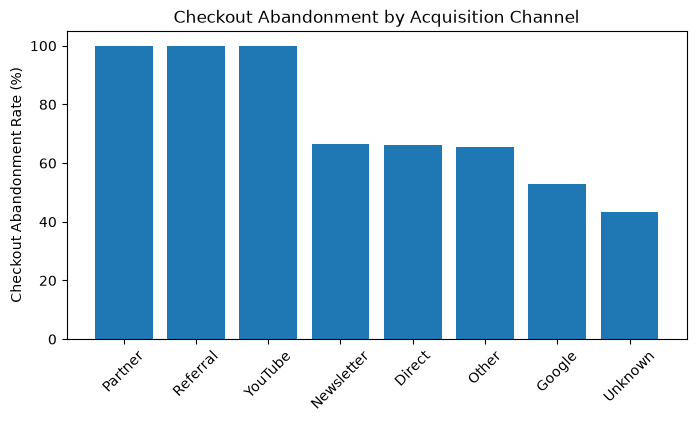

In [68]:
checkout_source = (
    df_checkout.groupby("acquisition_channel")["checkout_abandoned"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

checkout_source["checkout_abandoned"] *= 100

plt.figure(figsize=(8,4))
plt.bar(
    checkout_source["acquisition_channel"],
    checkout_source["checkout_abandoned"]
)
plt.ylabel("Checkout Abandonment Rate (%)")
plt.title("Checkout Abandonment by Acquisition Channel")
plt.xticks(rotation=45)
plt.show()

### Insight

Among acquisition channels with meaningful traffic volume, **Google** exhibits the lowest checkout abandonment rate (**52.8%**), while **Direct** and **Other** traffic experience substantially higher abandonment rates of approximately **66%**.

These differences suggest that users arriving through Google may have stronger purchase intent than users from other acquisition channels. Marketing source quality may therefore influence the likelihood of completing a purchase after entering the checkout process.

> **Note:** Channels such as Referral, YouTube, Newsletter, and Partner contain only a very small number of sessions and should therefore not be interpreted as representative.

### 3.4 Checkout Journey Analysis

In [72]:
pd.DataFrame({
    "Stage":[
        "Begin Checkout",
        "Shipping",
        "Payment",
        "Purchase"
    ],
    "Sessions":[
        (df_checkout["begin_checkout"]>0).sum(),
        (df_checkout["add_shipping_info"]>0).sum(),
        (df_checkout["add_payment_info"]>0).sum(),
        df_checkout["purchased"].sum()
    ]
})

,Stage,Sessions
0,Begin Checkout,11088
1,Shipping,11086
2,Payment,6808
3,Purchase,4842


### Insight

Almost all users who begin the checkout process proceed to the shipping information step, indicating that the initial checkout experience presents little friction.

The most substantial drop-off occurs between the **Shipping** and **Payment** stages, followed by a further reduction before purchase completion. These findings suggest that payment-related friction, additional costs, or last-minute purchase hesitation may represent the primary causes of checkout abandonment.

Optimizing the payment experience and reducing checkout complexity could therefore have a meaningful impact on overall conversion.

### 3.5 Checkout Performance by Country

In [73]:
country = (
    df_checkout.groupby("country")["checkout_abandoned"]
      .agg(["count","mean"])
      .reset_index()
)

country["abandonment_rate"] = country["mean"]*100

country.sort_values("count", ascending=False).head(10)

,country,count,mean,abandonment_rate
104,United States,4878,0.566831,56.683067
43,India,1004,0.548805,54.880478
18,Canada,858,0.552448,55.244755
103,United Kingdom,333,0.54955,54.954955
92,Spain,227,0.577093,57.709251
33,France,211,0.511848,51.184834
35,Germany,189,0.57672,57.671958
96,Taiwan,187,0.566845,56.684492
20,China,180,0.583333,58.333333
50,Japan,151,0.496689,49.668874


### Insight

Checkout abandonment rates remain relatively consistent across the largest user markets, generally ranging between **50%** and **58%**.

Although minor differences exist, no country demonstrates an exceptionally high or low abandonment rate. This suggests that checkout abandonment is a broadly consistent behavioural pattern rather than an issue confined to a particular geographic market.

## Key Findings

The checkout abandonment analysis reveals several important insights:

- More than **56%** of checkout sessions do not result in a completed purchase.
- Users who abandon checkout often browse more pages and products, suggesting that abandonment is not simply caused by low engagement.
- Checkout abandonment rates are broadly consistent across device categories and countries.
- Google-acquired users exhibit lower abandonment rates than Direct and Other traffic sources, indicating differences in acquisition quality.
- The largest checkout drop-off occurs between the **Shipping** and **Payment** stages, highlighting the payment process as the most promising area for product optimization.

## 5. Statistical Validation

In [82]:
purchase = df_checkout[df_checkout["purchased"]]["session_duration_sec"]

abandon = df_checkout[~df_checkout["purchased"]]["session_duration_sec"]

t_stat, p_value = ttest_ind(
    purchase,
    abandon,
    equal_var=False
)

print(t_stat)
print(p_value)

0.44908614927118223
0.6533789267973003


In [83]:
features = [
    "session_duration_sec",
    "total_events",
    "total_engagement_time",
    "pageviews",
    "unique_pages",
    "item_views",
    "searches"
]

results = []

for feature in features:

    purchase = df_checkout[df_checkout["purchased"]][feature]

    abandon = df_checkout[~df_checkout["purchased"]][feature]

    t_stat, p = ttest_ind(
        purchase,
        abandon,
        equal_var=False
    )

    results.append({
        "Feature": feature,
        "Purchase Mean": purchase.mean(),
        "Abandon Mean": abandon.mean(),
        "t-statistic": t_stat,
        "p-value": p
    })

results = pd.DataFrame(results)

results

,Feature,Purchase Mean,Abandon Mean,t-statistic,p-value
0,session_duration_sec,3117.052251,2893.192283,0.449086,6.533789e-01
1,total_events,108.045023,103.332853,2.815595,4.877291e-03
2,total_engagement_time,874194.361008,526353.500801,27.465572,4.438382e-159
3,pageviews,31.184634,35.259046,-6.877768,6.425147e-12
4,unique_pages,16.156753,25.522895,-21.585230,3.338949e-100
5,item_views,13.465717,14.791386,-3.985215,6.785121e-05
6,searches,0.374226,0.585335,-7.538883,5.157517e-14


### Independent t-test

An independent two-sample t-test was conducted to evaluate whether behavioural metrics differ significantly between purchased and non-purchased sessions.

The results indicate that **total events, engagement time, page views, unique pages, item views, and searches** all exhibit statistically significant differences (**p < 0.05**). By contrast, **session duration is not significantly different** between the two groups (p = 0.653).

These findings suggest that **interaction quality and behavioural engagement are stronger indicators of purchase behaviour than session duration alone**.

In [84]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df_checkout["device_category"],
    df_checkout["purchased"]
)

chi2, p, dof, expected = chi2_contingency(table)

print(chi2)
print(p)

2.3432429451338104
0.30986409756835087


### Chi-square Test

A Chi-square test was performed to examine the relationship between device category and purchase outcome.

The test produced **no statistically significant association** between device type and purchase behaviour (χ² = 2.34, p = 0.310).

This result supports the exploratory analysis, indicating that device category alone is unlikely to explain purchasing behaviour.

In [86]:
features = [
    "session_duration_sec",
    "total_events",
    "total_engagement_time",
    "pageviews",
    "unique_pages",
    "item_views",
    "searches",
    "add_to_cart",
    "begin_checkout",
    "add_shipping_info",
    "add_payment_info"
]

results = []

for feature in features:

    corr, p = pointbiserialr(
        df_prediction["purchased"].astype(int),
        df_prediction[feature]
    )

    results.append({
        "Feature": feature,
        "Correlation": corr,
        "P-value": p
    })

corr_df = (
    pd.DataFrame(results)
    .sort_values(
        "Correlation",
        ascending=False
    )
)

corr_df

,Feature,Correlation,P-value
10,add_payment_info,0.479394,0.000000e+00
2,total_engagement_time,0.262502,3.870631e-174
8,begin_checkout,0.216961,2.965823e-118
7,add_to_cart,0.213192,3.730477e-114
9,add_shipping_info,0.212694,1.282465e-113
1,total_events,0.025909,6.364825e-03
0,session_duration_sec,0.004005,6.732312e-01
5,item_views,-0.036782,1.070537e-04
3,pageviews,-0.061481,9.216287e-11
6,searches,-0.072308,2.475864e-14


### Point-biserial Correlation

Point-biserial correlation analysis was performed to measure the relationship between behavioural features and purchase outcome.

The strongest positive correlations were observed for **add_payment_info (r = 0.479)**, followed by **total engagement time (r = 0.263)** and **begin_checkout (r = 0.217)**.

These results indicate that behavioural engagement throughout the purchase journey is positively associated with conversion, supporting the inclusion of these variables in the purchase intent prediction model.